<a href="https://colab.research.google.com/github/ob3x/Learn-Ds/blob/main/Regresja_liniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
import numpy as np
import pandas as pd
import sklearn

np.set_printoptions(formatter=dict(float=lambda x: f"{x:.2f}"))

In [119]:
raw_data = pd.read_csv("Data.csv")
raw_data

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [120]:
df = raw_data.copy()
df.columns = [col.lower() for col in df.columns]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    10 non-null     object 
 1   age        9 non-null      float64
 2   salary     9 non-null      float64
 3   purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [121]:
for col in ["country", "purchased"]:
  df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   country    10 non-null     category
 1   age        9 non-null      float64 
 2   salary     9 non-null      float64 
 3   purchased  10 non-null     category
dtypes: category(2), float64(2)
memory usage: 568.0 bytes


In [122]:
df.isnull().sum()

,0
country,0
age,1
salary,1
purchased,0


In [123]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = "mean")
df[["age", "salary"]] = imputer.fit_transform(df[["age", "salary"]])
df

,country,age,salary,purchased
0,France,44.000000,72000.000000,No
1,Spain,27.000000,48000.000000,Yes
2,Germany,30.000000,54000.000000,No
3,Spain,38.000000,61000.000000,No
4,Germany,40.000000,63777.777778,Yes
5,France,35.000000,58000.000000,Yes
6,Spain,38.777778,52000.000000,No
7,France,48.000000,79000.000000,Yes
8,Germany,50.000000,83000.000000,No
9,France,37.000000,67000.000000,Yes


In [124]:
df["age"] = df["age"].astype("int")
df["salary"] = df["salary"].apply(lambda x: round(x, 2))
df

,country,age,salary,purchased
0,France,44,72000.00,No
1,Spain,27,48000.00,Yes
2,Germany,30,54000.00,No
3,Spain,38,61000.00,No
4,Germany,40,63777.78,Yes
5,France,35,58000.00,Yes
6,Spain,38,52000.00,No
7,France,48,79000.00,Yes
8,Germany,50,83000.00,No
9,France,37,67000.00,Yes


In [125]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
df["purchased"] = encoder.fit_transform(df[["purchased"]]).astype("int")
df

,country,age,salary,purchased
0,France,44,72000.00,1
1,Spain,27,48000.00,0
2,Germany,30,54000.00,1
3,Spain,38,61000.00,1
4,Germany,40,63777.78,0
5,France,35,58000.00,0
6,Spain,38,52000.00,1
7,France,48,79000.00,0
8,Germany,50,83000.00,1
9,France,37,67000.00,0


In [126]:
encoder.categories_

[array(['No', 'Yes'], dtype=object)]

In [128]:
df = pd.get_dummies(df, columns=["country"], drop_first=True).astype("int")
df

,age,salary,purchased,country_Germany,country_Spain
0,44,72000,1,0,0
1,27,48000,0,0,1
2,30,54000,1,1,0
3,38,61000,1,0,1
4,40,63777,0,1,0
5,35,58000,0,0,0
6,38,52000,1,0,1
7,48,79000,0,0,0
8,50,83000,1,1,0
9,37,67000,0,0,0


In [137]:
x = df.drop("purchased", axis=1)
y = df["purchased"]
print(f"x shape : {x.shape}")
print(f"y shape : {y.shape}")

df

x shape : (10, 4)
y shape : (10,)


,age,salary,purchased,country_Germany,country_Spain
0,44,72000,1,0,0
1,27,48000,0,0,1
2,30,54000,1,1,0
3,38,61000,1,0,1
4,40,63777,0,1,0
5,35,58000,0,0,0
6,38,52000,1,0,1
7,48,79000,0,0,0
8,50,83000,1,1,0
9,37,67000,0,0,0


In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

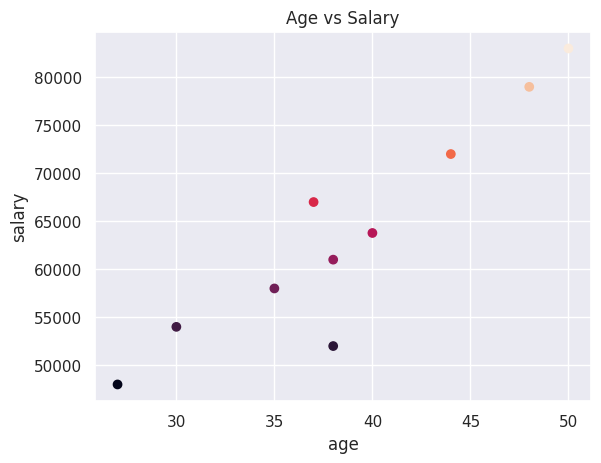


Średnie zarobki w Niemczech 66925.67
Średnie zarobki w Hiszpani 53666.67
Średnie zarobki w Francji 69000.0


In [163]:
plt.title("Age vs Salary")
plt.scatter(df["age"], df["salary"], c=df["salary"])
plt.xlabel("age")
plt.ylabel("salary")
plt.show()

print(f"\nŚrednie zarobki w Niemczech {round(df["salary"][df['country_Germany'] == 1].mean(), 2)}")
print(f"Średnie zarobki w Hiszpani {round(df["salary"][df['country_Spain'] == 1].mean(), 2)}")
print(f"Średnie zarobki w Francji {round(df["salary"][(df['country_Spain'] == 0) & (df['country_Germany'] == 0)].mean(), 2)}")

In [170]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["age", "salary"]] = scaler.fit_transform(df[["age", "salary"]])
df

,age,salary,purchased,country_Germany,country_Spain
0,0.769734,0.749480,1,0,0
1,-1.699225,-1.438171,0,0,1
2,-1.263526,-0.891258,1,1,0
3,-0.101663,-0.253193,1,0,1
4,0.188803,-0.000064,0,1,0
5,-0.537362,-0.526650,0,0,0
6,-0.101663,-1.073563,1,0,1
7,1.350666,1.387545,0,0,0
8,1.641132,1.752154,1,1,0
9,-0.246896,0.293720,0,0,0


In [178]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"x_train shape : {x_train.shape}")
print(f"x_test shape : {x_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

x_train shape : (8, 4)
x_test shape : (2, 4)
y_train shape : (8,)
y_test shape : (2,)


In [190]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(f"R2 score {r2_score(y_test, y_pred)}")

R2 score -2.6390479483621436
